In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats

In [2]:
df = pd.read_csv('../../data/raw/donnees.csv')
print(df.head())

       Notes   Assiduité  target
0   4.718613   13.203521       0
1   4.868307   30.633056       0
2  19.908331  100.000000       1
3  12.195317   63.822769       1
4   9.023127   47.757278       0


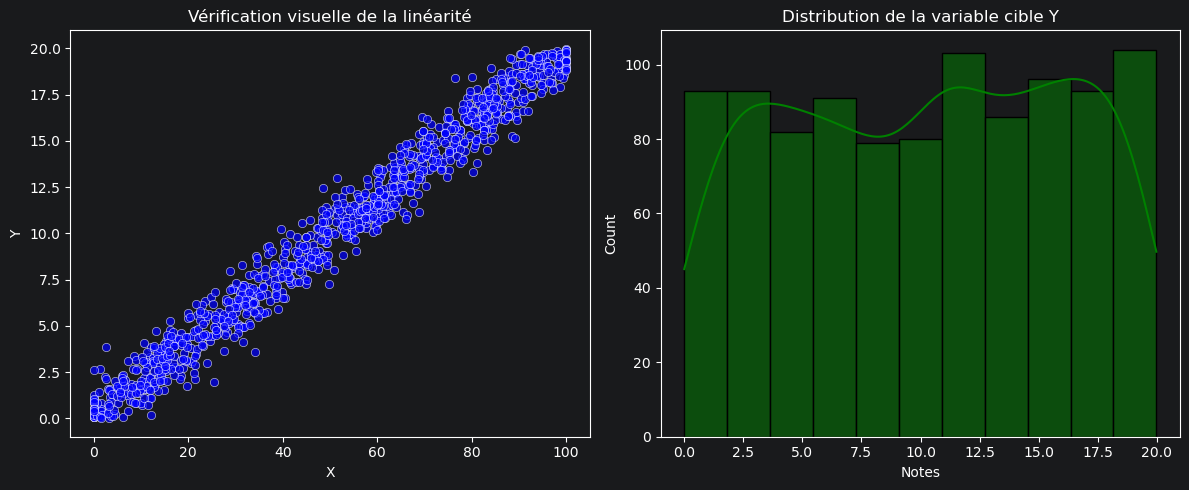

Coefficient de corrélation de Pearson : 0.9869


In [3]:
plt.figure(figsize=(12, 5))

# Graphique 1 : Nuage de points (Scatter Plot)
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="Assiduité", y="Notes", color='blue', alpha=0.7)
plt.title("Vérification visuelle de la linéarité")
plt.xlabel("X")
plt.ylabel("Y")

# Graphique 2 : Distribution de la variable cible
plt.subplot(1, 2, 2)
sns.histplot(df['Notes'], kde=True, color='green')
plt.title("Distribution de la variable cible Y")

plt.tight_layout()
plt.show()

# Calcul de la corrélation de Pearson
correlation = df['Assiduité'].corr(df['Notes'])
print(f"Coefficient de corrélation de Pearson : {correlation:.4f}")


In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(
    df[['Assiduité']], df['Notes'], test_size=0.2, random_state=42
)

print(f"Taille entraînement : {X_train.shape[0]} lignes")
print(f"Taille test : {X_test.shape[0]} lignes")


Taille entraînement : 800 lignes
Taille test : 200 lignes


In [7]:
# Initialisation du modèle
model_sklearn = LinearRegression()

# Entraînement du modèle
model_sklearn.fit(X_train, Y_train)

# Extraction des coefficients
pente_sklearn = model_sklearn.coef_[0]
intercepte_sklearn = model_sklearn.intercept_

print(f"[Scikit-Learn] Pente : {pente_sklearn:.4f}")
print(f"[Scikit-Learn] Intercepte : {intercepte_sklearn:.4f}")

# Prédiction sur le jeu de test
Y_pred_test = model_sklearn.predict(X_test)


{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}
[Scikit-Learn] Pente : 0.1959
[Scikit-Learn] Intercepte : 0.2197


In [8]:
mse = mean_squared_error(Y_test, Y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred_test)

print("\n--- PERFORMANCES DU MODELE (TEST) ---")
print(f"Erreur Quadratique Moyenne (MSE) : {mse:.4f}")
print(f"Racine de la MSE (RMSE) : {rmse:.4f} (Le modèle se trompe en moyenne de ± {rmse:.2f} unités)")
print(f"Coefficient de détermination (R²) : {r2:.4f} ({r2*100:.1f}% de la variance de Y est expliquée par X)")



--- PERFORMANCES DU MODELE (TEST) ---
Erreur Quadratique Moyenne (MSE) : 0.9125
Racine de la MSE (RMSE) : 0.9552 (Le modèle se trompe en moyenne de ± 0.96 unités)
Coefficient de détermination (R²) : 0.9736 (97.4% de la variance de Y est expliquée par X)


In [9]:
# Statsmodels requiert l'ajout explicite d'une constante pour l'intercepte
X_train_stat = sm.add_constant(X_train)

# Ajustement du modèle OLS
model_statsmodels = sm.OLS(Y_train, X_train_stat).fit()

# Affichage du rapport complet
print(model_statsmodels.summary())


                            OLS Regression Results                            
Dep. Variable:                  Notes   R-squared:                       0.974
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                 2.991e+04
Date:                Sat, 04 Jul 2026   Prob (F-statistic):               0.00
Time:                        00:05:13   Log-Likelihood:                -1087.6
No. Observations:                 800   AIC:                             2179.
Df Residuals:                     798   BIC:                             2189.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2197      0.067      3.301      0.0

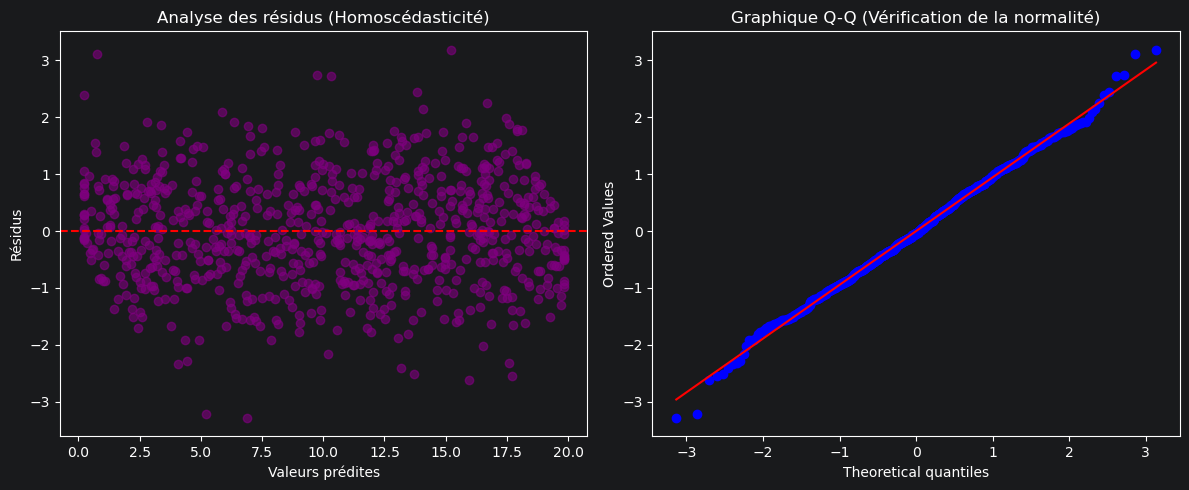

In [11]:
# Calcul des résidus sur le jeu d'entraînement
Y_train_pred = model_sklearn.predict(X_train)
residus = Y_train - Y_train_pred

plt.figure(figsize=(12, 5))

# 1. Graphique de l'Homoscédasticité (Dispersion constante des erreurs)
plt.subplot(1, 2, 1)
plt.scatter(Y_train_pred, residus, color='purple', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Analyse des résidus (Homoscédasticité)")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")

# 2. Graphique Q-Q Plot (Normalité des résidus)
plt.subplot(1, 2, 2)
stats.probplot(residus, plot=plt)
plt.title("Graphique Q-Q (Vérification de la normalité)")

plt.tight_layout()
plt.show()


/home/atangana/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


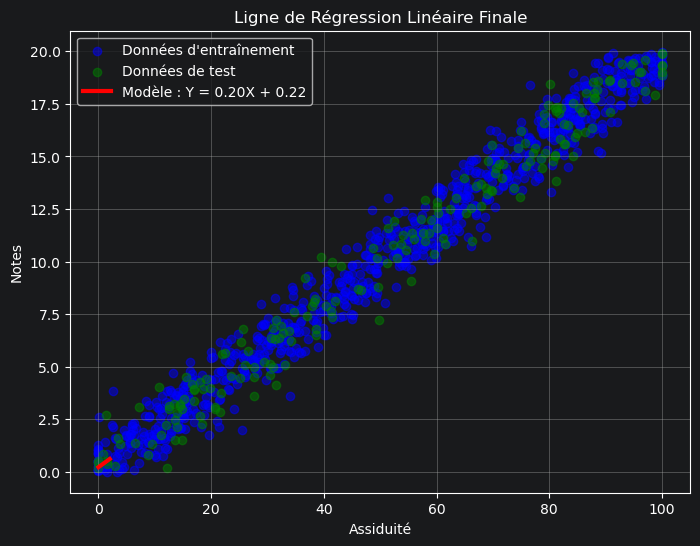

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(X_train, Y_train, color='blue', alpha=0.5, label='Données d\'entraînement')
plt.scatter(X_test, Y_test, color='green', alpha=0.5, label='Données de test')

# Génération de la ligne de régression
X_ligne = np.linspace(0, 2, 100).reshape(-1, 1)
Y_ligne = model_sklearn.predict(X_ligne)

plt.plot(X_ligne, Y_ligne, color='red', linewidth=3, label=f'Modèle : Y = {pente_sklearn:.2f}X + {intercepte_sklearn:.2f}')
plt.title("Ligne de Régression Linéaire Finale")
plt.xlabel("Assiduité")
plt.ylabel("Notes")
plt.legend()
plt.grid(True)
plt.show()
